# Persistent activity and bistability

In [25]:
%matplotlib inline
import numpy as np
import numpy as numpy
import scipy.integrate
from matplotlib import pyplot as plt

### Define activation function

In [26]:
def F(x):
    return 1/(1+np.exp(-beta*(x-gamma)))

beta=4.0
gamma=0.7

### TODO: Plot activation function; what do parameters $\beta$ and $\gamma$ correspond to?

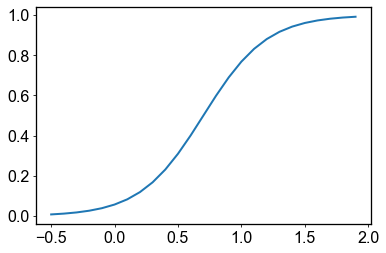

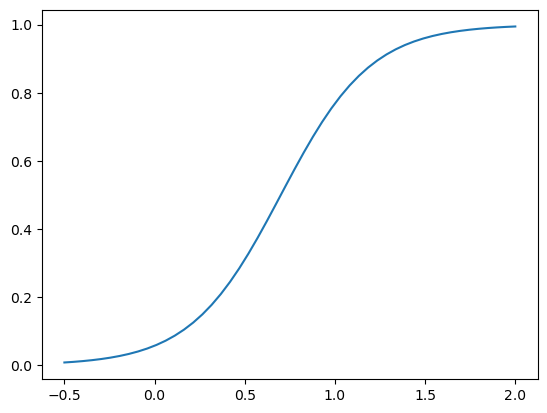

In [27]:
x = np.linspace(-0.5, 2)
y = F(x)
plt.plot(x, y)

### Define dynamics

In [28]:
def IntegrateAuto(X, t):
    dXdT=-X+numpy.dot(J, F(X))+I
    return dXdT

I=0
J=.5

### Integrate dynamics starting from initial condition x0 (t is vector; outputs a vector x(t))

In [29]:
def LookActAuto(_t,_x0):
    _x=scipy.integrate.odeint(IntegrateAuto,_x0,_t)
    return _x

### TODO: Plot dXdT as function of x

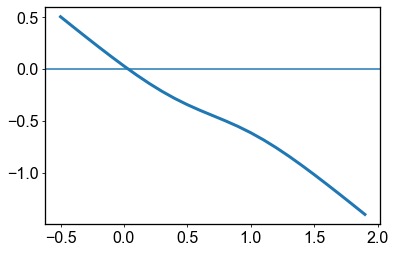

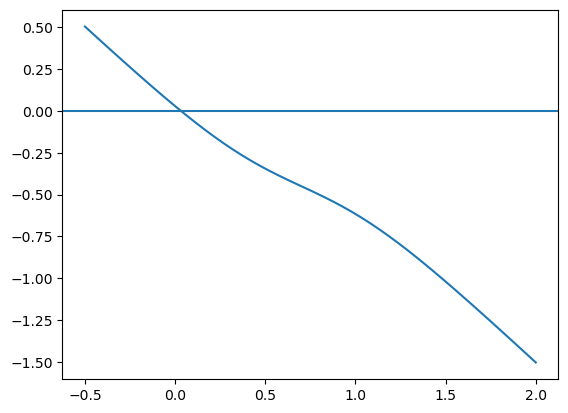

In [30]:
t = np.arange(-0.5, 2, 100)
dxdt = IntegrateAuto(x, 0)
plt.plot(x, dxdt)
plt.axhline(0)

### TODO: Predict the dynamics and run the dynamics from several initial conditions

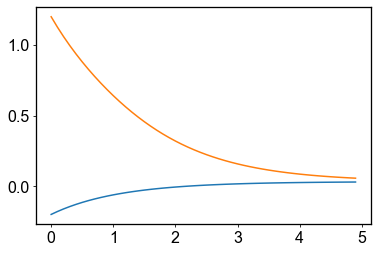

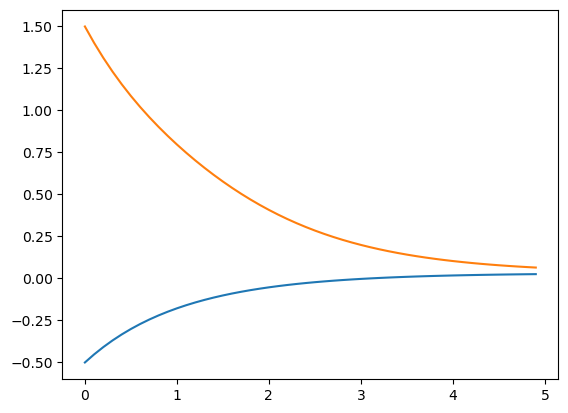

In [31]:
t = np.arange(0, 5, 0.1)

x0 = -0.5
x = LookActAuto(t,x0)
plt.plot(t,x)

x1 = 1.5
x = LookActAuto(t,x1)
plt.plot(t,x)

### TODO: Find coupling J for which the network is bistable

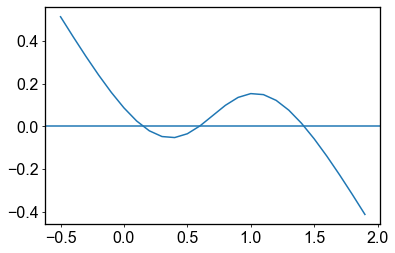

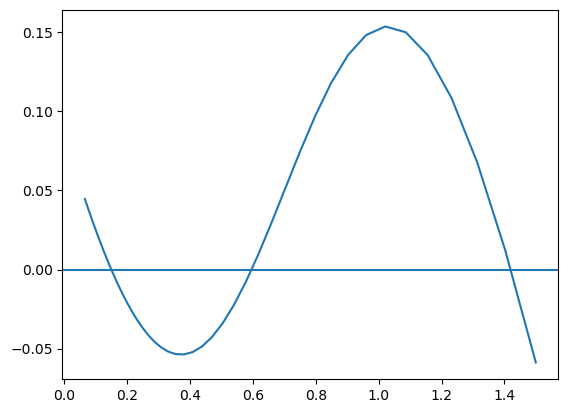

In [32]:
J = 1.5

t = np.linspace(-0.5, 2, 100)
dxdt = IntegrateAuto(x, 0)
plt.plot(x, dxdt)
plt.axhline(0)

### TODO: Run the dynamics from several initial conditions in a bistable network

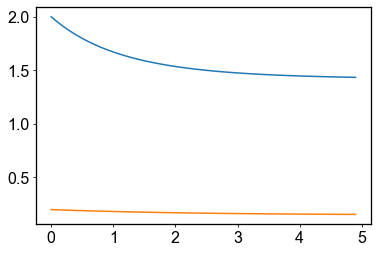

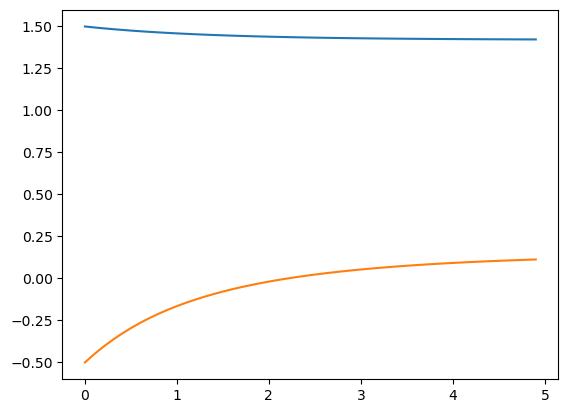

In [34]:
t = np.arange(0, 5, 0.1)

x0 = 1.5
x = LookActAuto(t, x0)
plt.plot(t, x)

x1 = -0.5
x = LookActAuto(t, x1)
plt.plot(t, x)

### TODO: Simulate a trial of a working memory experiment

In [35]:
##Definition of task parameters

T_stim_on=50;
Stim_duration=10;
T_delay=200;
T_erase=10;

deltat=0.1

t_spont=np.arange(0,T_stim_on,deltat)
t_stim=np.arange(0,Stim_duration,deltat)
t_delay=np.arange(0,T_delay,deltat)
t_erase=np.arange(0,T_erase,deltat)
t_spont2=np.arange(0,T_stim_on,deltat)

x0=0

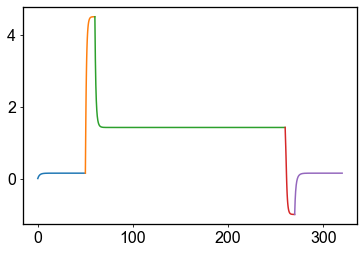

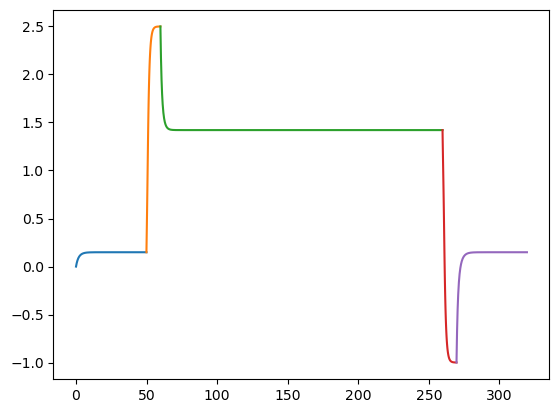

In [36]:
# Spontaneous activity
I = 0
x = LookActAuto(t_spont, x0)
plt.plot(t_spont, x)

# Stimulus
I = 1
x = LookActAuto(t_stim, x[-1])
plt.plot(t_stim + t_spont[-1], x)

# Delay
I = 0
x = LookActAuto(t_delay, x[-1])
plt.plot(t_delay + t_spont[-1] + t_stim[-1], x)


# Erase
I = -1
x = LookActAuto(t_erase, x[-1])
plt.plot(t_erase + t_spont[-1] + t_stim[-1] + t_delay[-1], x)

# Spontaneous activity 2
I = 0
x = LookActAuto(t_spont2, x[-1])
plt.plot(t_spont2 + t_spont[-1] + t_stim[-1] + t_delay[-1] + t_erase[-1], x)